# Reading the file


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/DSGP_Final_LabeledData.csv')

In [ ]:
df.head()

,Date,T2M,T2MDEW,TS,T2M_RANGE,QV2M,RH2M,GWETTOP,GWETROOT,1_month_rainfall_aggregate,1_month_rainfall_aggregate_avg,Cluster_Label,Irrigation_Label
0,1/1/1990,25.438333,22.776667,25.558333,4.303333,17.335000,85.625000,0.646667,0.578333,246.1120,301.2839,0,Do Not Irrigate
1,1/11/1990,24.637000,21.199000,24.792000,5.206000,15.753000,81.599000,0.714000,0.668000,201.8966,237.2716,0,Do Not Irrigate
2,1/21/1990,24.559333,20.202667,24.854000,7.052667,14.798667,77.519333,0.586000,0.571333,192.2845,180.1767,0,Do Not Irrigate
3,2/1/1990,25.503333,20.528333,26.280000,7.721667,15.055000,75.051667,0.503333,0.521667,40.6034,143.8716,1,Irrigate
4,2/11/1990,27.009000,22.133000,27.867000,6.830000,16.651000,75.986000,0.456000,0.490000,15.9914,107.4868,1,Irrigate


Skipping boxplot for column 'Date' as it is not numeric.


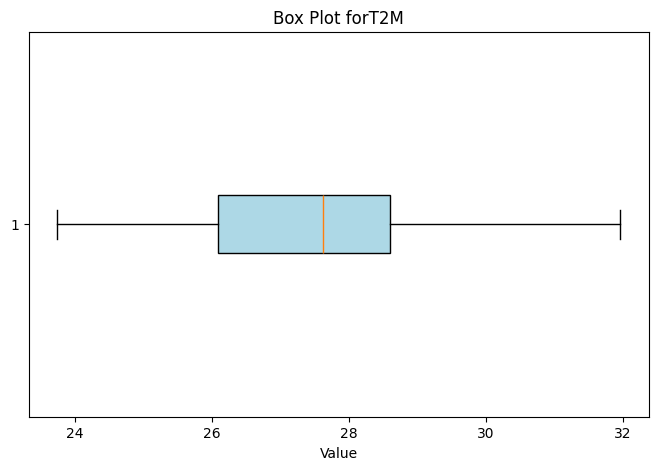

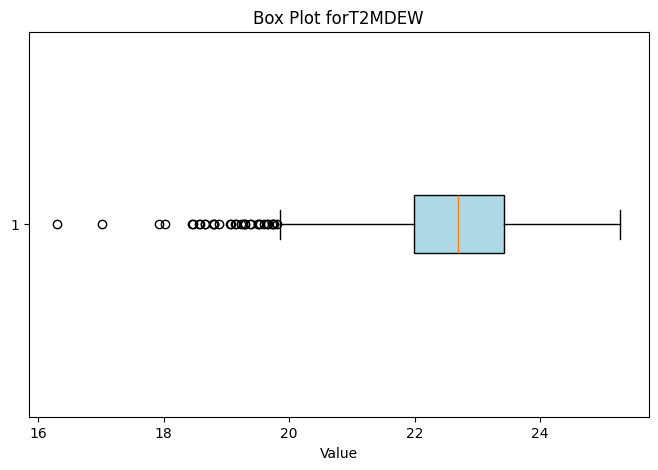

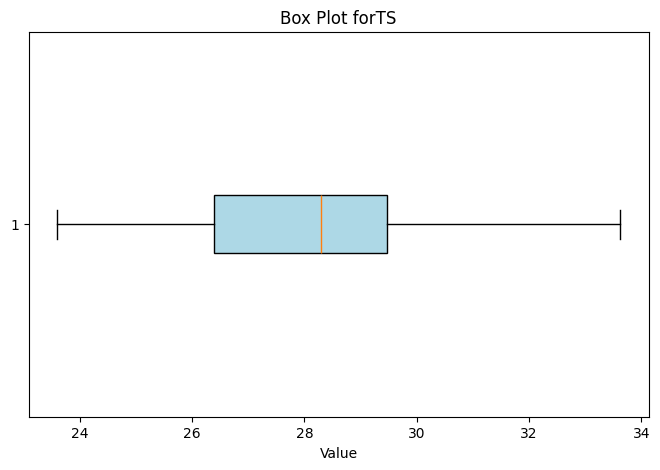

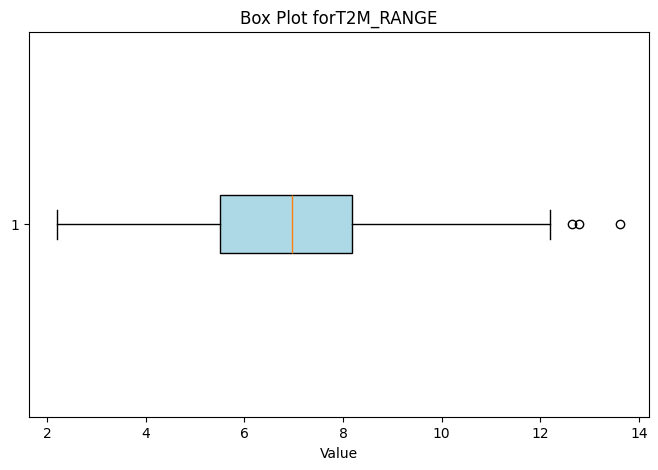

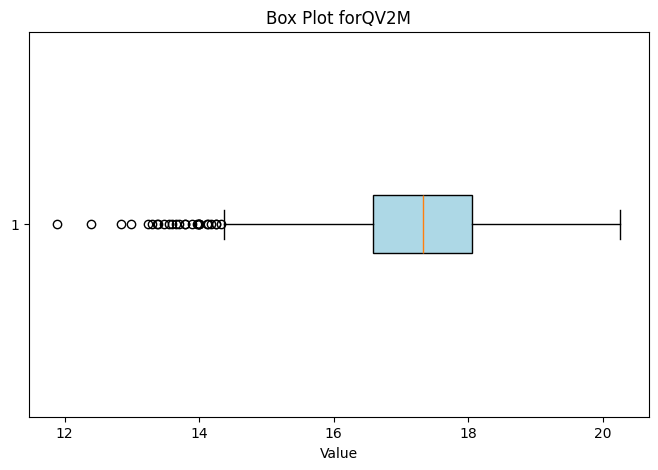

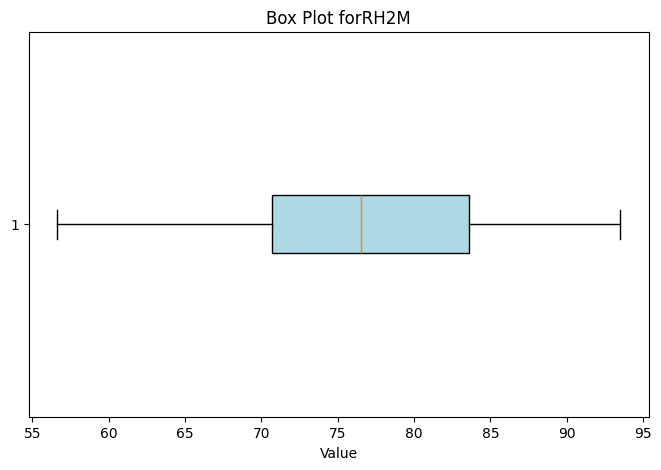

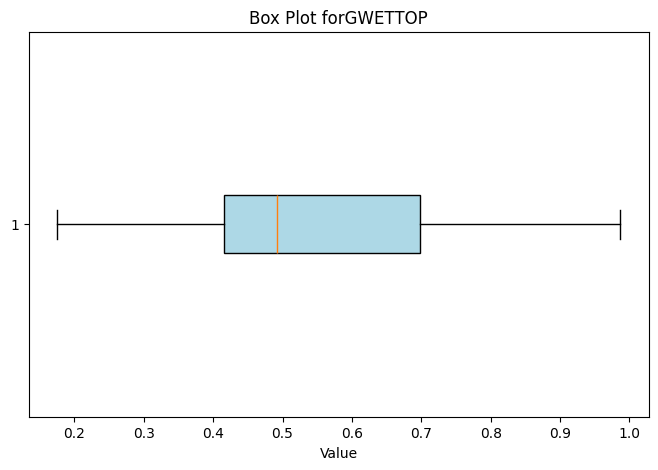

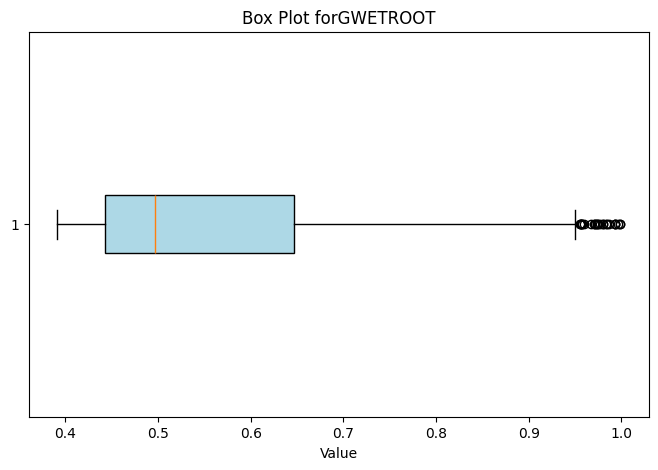

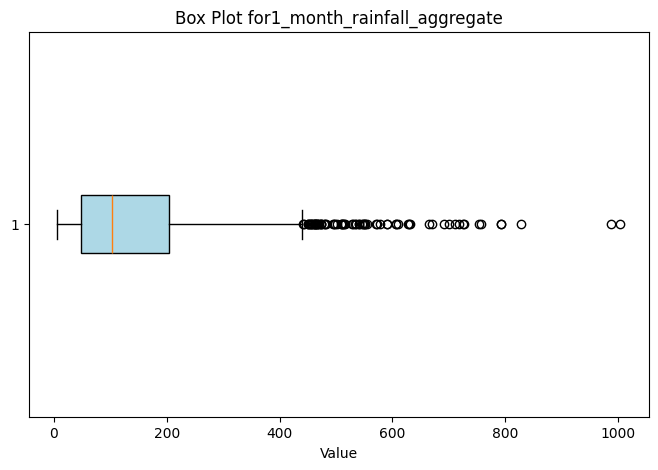

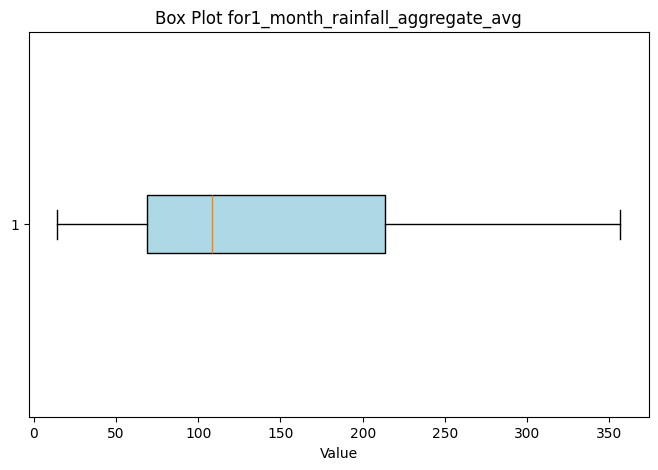

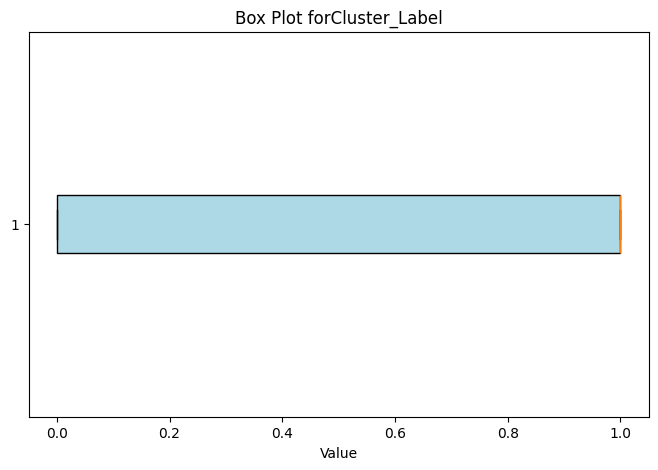

Skipping boxplot for column 'Irrigation_Label' as it is not numeric.


In [ ]:
# Loop through columns, but exclude the 'Date' column (or other non-numeric columns)
for col in df.columns:
    if df[col].dtype in [int, float]:  # Check if the column's data type is numeric
        plt.figure(figsize=(8, 5))
        plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
        plt.title("Box Plot for"+col)
        plt.xlabel("Value")
        plt.show() # Add plt.show() to display each boxplot individually
    else:
        print(f"Skipping boxplot for column '{col}' as it is not numeric.")

In [ ]:
df.drop(['Irrigation_Label','Date','T2MDEW','TS','GWETTOP'], axis=1, inplace=True)

In [ ]:
corelation_matrix=df.corr(method="pearson")
print(corelation_matrix)

                                     T2M  T2M_RANGE      QV2M      RH2M  \
T2M                             1.000000   0.742896  0.064296 -0.773702   
T2M_RANGE                       0.742896   1.000000 -0.492863 -0.910292   
QV2M                            0.064296  -0.492863  1.000000  0.577986   
RH2M                           -0.773702  -0.910292  0.577986  1.000000   
GWETROOT                       -0.755428  -0.766488  0.330966  0.840680   
1_month_rainfall_aggregate     -0.489435  -0.628784  0.339440  0.630837   
1_month_rainfall_aggregate_avg -0.562904  -0.588534  0.157237  0.574421   
Cluster_Label                   0.744095   0.784529 -0.349120 -0.839533   

                                GWETROOT  1_month_rainfall_aggregate  \
T2M                            -0.755428                   -0.489435   
T2M_RANGE                      -0.766488                   -0.628784   
QV2M                            0.330966                    0.339440   
RH2M                            0.84

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
df['rainfall'] = np.log1p(df['1_month_rainfall_aggregate'])
df['specificHumidity'] = np.log1p(df['QV2M'])
df['temprange']=np.log1p(df['T2M_RANGE'])
df['rootSoilMoist']=np.log1p(df['GWETROOT'])

In [ ]:
df.head()

,T2M,RH2M,1_month_rainfall_aggregate_avg,Cluster_Label,rainfall,specificHumidity,temprange,rootSoilMoist
0,25.438333,85.625000,301.2839,0,5.509842,2.908812,1.668336,0.456369
1,24.637000,81.599000,237.2716,0,5.312696,2.818577,1.825517,0.511625
2,24.559333,77.519333,180.1767,0,5.264163,2.759926,2.086003,0.451925
3,25.503333,75.051667,143.8716,1,3.728182,2.776020,2.165810,0.419806
4,27.009000,75.986000,107.4868,1,2.832707,2.870792,2.057963,0.398776


In [ ]:
df.drop(['1_month_rainfall_aggregate','QV2M','T2M_RANGE','GWETROOT'], axis=1, inplace=True)

In [ ]:
df.head()

,T2M,RH2M,1_month_rainfall_aggregate_avg,Cluster_Label,rainfall,specificHumidity,temprange,rootSoilMoist
0,25.438333,85.625000,301.2839,0,5.509842,2.908812,1.668336,0.456369
1,24.637000,81.599000,237.2716,0,5.312696,2.818577,1.825517,0.511625
2,24.559333,77.519333,180.1767,0,5.264163,2.759926,2.086003,0.451925
3,25.503333,75.051667,143.8716,1,3.728182,2.776020,2.165810,0.419806
4,27.009000,75.986000,107.4868,1,2.832707,2.870792,2.057963,0.398776


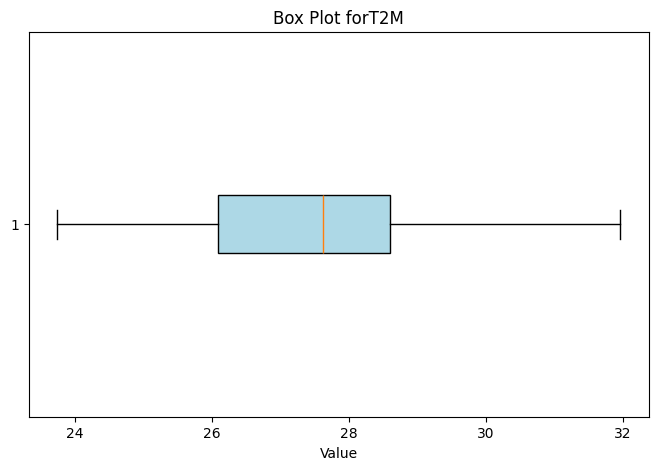

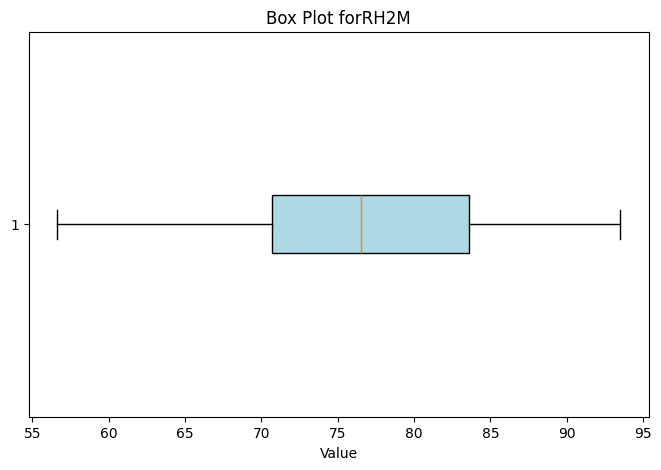

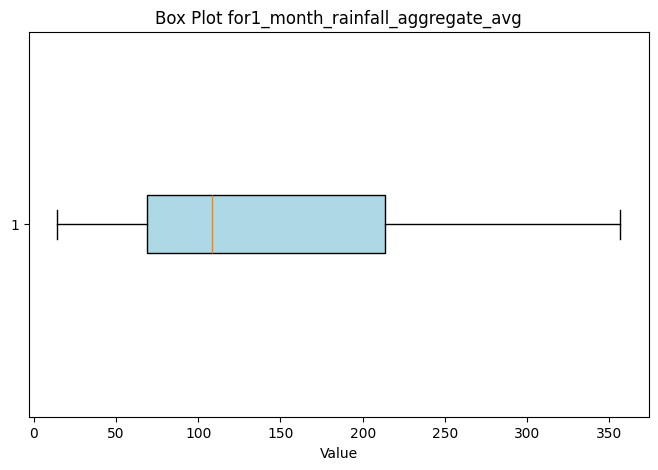

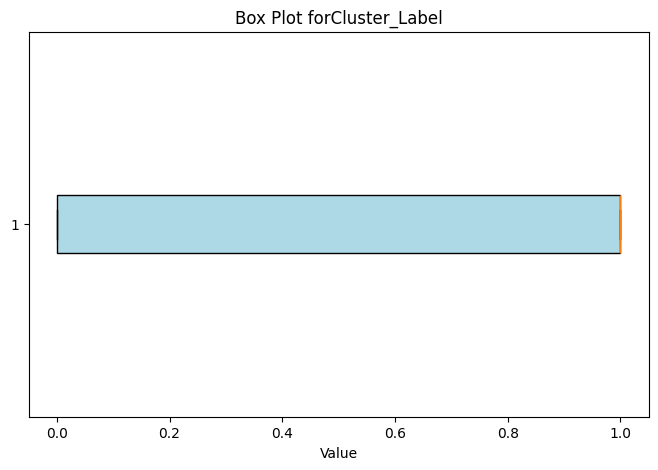

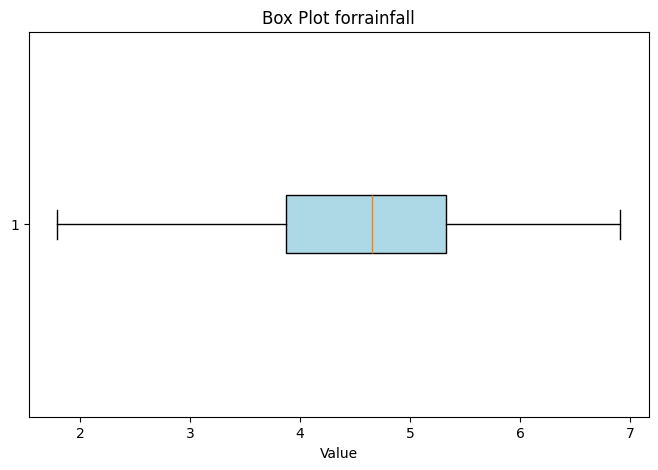

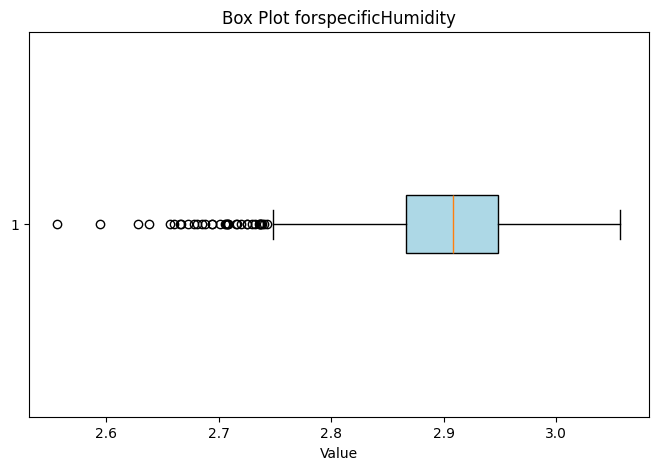

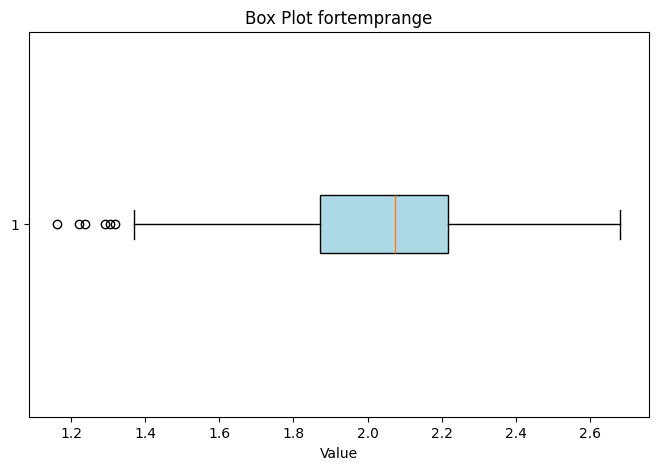

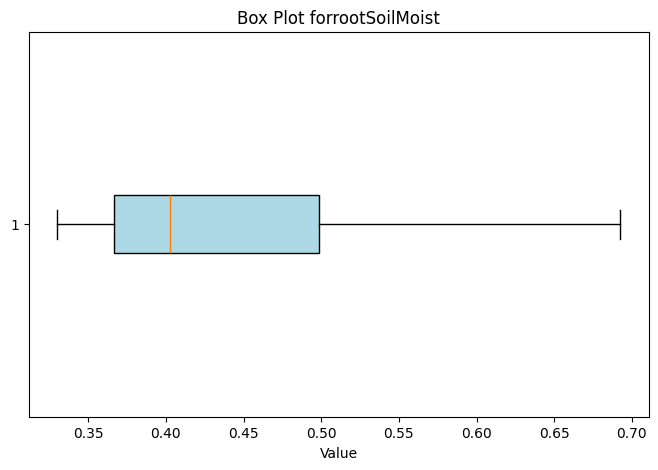

In [ ]:
# Loop through columns, but exclude the 'Date' column (or other non-numeric columns)
for col in df.columns:
    if df[col].dtype in [int, float]:  # Check if the column's data type is numeric
        plt.figure(figsize=(8, 5))
        plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
        plt.title("Box Plot for"+col)
        plt.xlabel("Value")
        plt.show() # Add plt.show() to display each boxplot individually
    else:
        print(f"Skipping boxplot for column '{col}' as it is not numeric.")

# Selecting Features with more Importance


                          Feature  Importance
1                            RH2M    0.348219
6                   rootSoilMoist    0.227470
5                       temprange    0.172838
0                             T2M    0.118681
3                        rainfall    0.067303
2  1_month_rainfall_aggregate_avg    0.041227
4                specificHumidity    0.024263


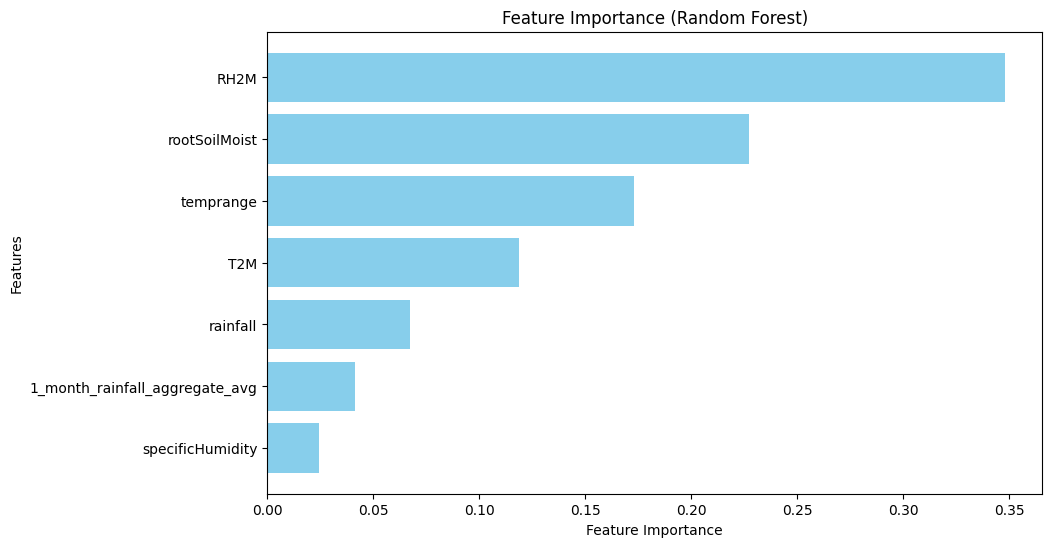

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

x_train=df.drop(columns=['Cluster_Label'])
y_train=df['Cluster_Label']

# Train a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

# Get feature importances
feature_importances = rf.feature_importances_

# Map feature importances to feature names
features = x_train.columns  # Feature names from your dataset
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top features
print(importance_df)

# Visualize the feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


# Used Min Max Scaler to normalize the dataset

In [ ]:
from sklearn.preprocessing import MinMaxScaler
X=df[df.columns[:10]]

scaler=MinMaxScaler()
X_scale=scaler.fit_transform(X)
X_scale_df=pd.DataFrame(X_scale, columns=X.columns)
X_scale_df.head()


,T2M,RH2M,1_month_rainfall_aggregate_avg,Cluster_Label,rainfall,specificHumidity,temprange,rootSoilMoist
0,0.206610,0.786125,0.838199,0.0,0.726210,0.704352,0.333340,0.348853
1,0.109124,0.677060,0.651413,0.0,0.687749,0.524308,0.436627,0.501130
2,0.099676,0.566542,0.484811,0.0,0.678281,0.407280,0.607800,0.336604
3,0.214517,0.499693,0.378874,1.0,0.378624,0.439394,0.660243,0.248090
4,0.397689,0.525004,0.272704,1.0,0.203924,0.628493,0.589373,0.190134


In [ ]:
df.columns

Index(['T2M', 'RH2M', '1_month_rainfall_aggregate_avg', 'Cluster_Label',
       'rainfall', 'specificHumidity', 'temprange', 'rootSoilMoist'],
      dtype='object')

# Apply PCA

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(0.95)
X_pca=pca.fit_transform(df[['1_month_rainfall_aggregate_avg','specificHumidity','rainfall']])

explained_variance=pca.explained_variance_ratio_
explained_variance

array([0.99995036])

In [ ]:
import numpy as np
pca_columns = X_pca[:, :1]
pca_data = np.concatenate([pca_columns], axis=1)
pca_df = pd.DataFrame(pca_data, columns=['PCACOMP1'])

pca_df.head()
dataset_with_pca = pd.concat([X_scale_df, pca_df], axis=1)
dataset_with_pca.head()

,T2M,RH2M,1_month_rainfall_aggregate_avg,Cluster_Label,rainfall,specificHumidity,temprange,rootSoilMoist,PCACOMP1
0,0.206610,0.786125,0.838199,0.0,0.726210,0.704352,0.333340,0.348853,151.705814
1,0.109124,0.677060,0.651413,0.0,0.687749,0.524308,0.436627,0.501130,87.693701
2,0.099676,0.566542,0.484811,0.0,0.678281,0.407280,0.607800,0.336604,30.599865
3,0.214517,0.499693,0.378874,1.0,0.378624,0.439394,0.660243,0.248090,-5.715133
4,0.397689,0.525004,0.272704,1.0,0.203924,0.628493,0.589373,0.190134,-42.105319


In [ ]:
dataset_with_pca.drop(['1_month_rainfall_aggregate_avg','specificHumidity','rainfall'], inplace=True, axis=1)

In [ ]:
dataset_with_pca.head()

,T2M,RH2M,Cluster_Label,temprange,rootSoilMoist,PCACOMP1
0,0.206610,0.786125,0.0,0.333340,0.348853,151.705814
1,0.109124,0.677060,0.0,0.436627,0.501130,87.693701
2,0.099676,0.566542,0.0,0.607800,0.336604,30.599865
3,0.214517,0.499693,1.0,0.660243,0.248090,-5.715133
4,0.397689,0.525004,1.0,0.589373,0.190134,-42.105319


In [ ]:
from sklearn.decomposition import PCA
pca=PCA(0.95)
X_pca=pca.fit_transform(dataset_with_pca[['T2M','temprange']])
explained_variance=pca.explained_variance_ratio_
explained_variance

array([0.87604871, 0.12395129])

In [ ]:
import numpy as np
pca_columns = X_pca[:, :1]
pca_data = np.concatenate([pca_columns], axis=1)
pca_df = pd.DataFrame(pca_data, columns=['temp'])

pca_df.head()
dataset_with_pca2 = pd.concat([dataset_with_pca,pca_df], axis=1)
dataset_with_pca2.head()

,T2M,RH2M,Cluster_Label,temprange,rootSoilMoist,PCACOMP1,temp
0,0.206610,0.786125,0.0,0.333340,0.348853,151.705814,-0.340549
1,0.109124,0.677060,0.0,0.436627,0.501130,87.693701,-0.350461
2,0.099676,0.566542,0.0,0.607800,0.336604,30.599865,-0.249253
3,0.214517,0.499693,1.0,0.660243,0.248090,-5.715133,-0.127191
4,0.397689,0.525004,1.0,0.589373,0.190134,-42.105319,-0.030460


In [ ]:
dataset_with_pca2.drop(['T2M','temprange','Cluster_Label'], inplace=True, axis=1)

# Merging label data

In [ ]:
main_df=pd.concat([df['Cluster_Label'],dataset_with_pca2], axis=1)
main_df.head()

,Cluster_Label,RH2M,rootSoilMoist,PCACOMP1,temp
0,0,0.786125,0.348853,151.705814,-0.340549
1,0,0.677060,0.501130,87.693701,-0.350461
2,0,0.566542,0.336604,30.599865,-0.249253
3,1,0.499693,0.248090,-5.715133,-0.127191
4,1,0.525004,0.190134,-42.105319,-0.030460


In [ ]:
corelation_matrix=dataset_with_pca.corr(method="pearson")
print(corelation_matrix)

                    T2M      RH2M  Cluster_Label  temprange  rootSoilMoist  \
T2M            1.000000 -0.773702       0.744095   0.745642      -0.767080   
RH2M          -0.773702  1.000000      -0.839533  -0.908966       0.856745   
Cluster_Label  0.744095 -0.839533       1.000000   0.798465      -0.816844   
temprange      0.745642 -0.908966       0.798465   1.000000      -0.805019   
rootSoilMoist -0.767080  0.856745      -0.816844  -0.805019       1.000000   
PCACOMP1      -0.562908  0.574436      -0.618182  -0.627410       0.562455   

               PCACOMP1  
T2M           -0.562908  
RH2M           0.574436  
Cluster_Label -0.618182  
temprange     -0.627410  
rootSoilMoist  0.562455  
PCACOMP1       1.000000  


In [ ]:
main_df.to_csv('DSGP1.csv', index=False)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier



X=df.drop(columns=['Cluster_Label'])
Y=df['Cluster_Label']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

from sklearn.metrics import classification_report
y_pred=rf.predict(X_test)
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       140
           1       0.98      0.99      0.98       217

    accuracy                           0.98       357
   macro avg       0.98      0.98      0.98       357
weighted avg       0.98      0.98      0.98       357



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression  # Corrected the import statement
from sklearn.metrics import log_loss, classification_report
import numpy as np

# Prepare the dataset (replace df with your actual dataframe)
X = df.drop(columns=['Cluster_Label'])
Y = df['Cluster_Label']

# Perform the train-test split only once
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Initialize the Logistic Regression model once
log_reg = LogisticRegression(random_state=42, max_iter=1000)
# Simulate multiple training epochs (iterations)
training_losses = []
validation_losses = []

for epoch in range(10):  # Simulating 10 epochs
    # Train the Logistic Regression model
    log_reg.fit(X_train, Y_train)

    # Predict probabilities for log loss calculation
    y_train_prob = log_reg.predict_proba(X_train)  # Probabilities using log_reg
    y_test_prob = log_reg.predict_proba(X_test)    # Probabilities using log_reg

    # Calculate log loss (training and validation)
    train_loss = log_loss(Y_train, y_train_prob)
    val_loss = log_loss(Y_test, y_test_prob)

    training_losses.append(train_loss)
    validation_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Training Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}")

# Generate classification report for validation data
y_pred = log_reg.predict(X_test)  # Predictions using log_reg
print(classification_report(Y_test, y_pred))


Epoch 1: Training Loss = 0.0320, Validation Loss = 0.0623
Epoch 2: Training Loss = 0.0320, Validation Loss = 0.0623
Epoch 3: Training Loss = 0.0320, Validation Loss = 0.0623
Epoch 4: Training Loss = 0.0320, Validation Loss = 0.0623
Epoch 5: Training Loss = 0.0320, Validation Loss = 0.0623
Epoch 6: Training Loss = 0.0320, Validation Loss = 0.0623
Epoch 7: Training Loss = 0.0320, Validation Loss = 0.0623
Epoch 8: Training Loss = 0.0320, Validation Loss = 0.0623
Epoch 9: Training Loss = 0.0320, Validation Loss = 0.0623
Epoch 10: Training Loss = 0.0320, Validation Loss = 0.0623
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       140
           1       0.98      0.98      0.98       217

    accuracy                           0.97       357
   macro avg       0.97      0.97      0.97       357
weighted avg       0.97      0.97      0.97       357



In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier()
scores = cross_val_score(rf_classifier, X, Y, cv=5, scoring='f1_macro')
print("Cross-Validation F1-Scores:", scores)
print("Mean F1-Score:", scores.mean())

Cross-Validation F1-Scores: [0.96928636 0.97834907 0.99562781 0.97814983 0.97828437]
Mean F1-Score: 0.9799394905189664


In [ ]:
import torch
from torch.utils.data import DataLoader, random_split, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Convert the DataFrame to PyTorch tensors
# Assuming 'Cluster_Label' is your target variable
inputs = torch.tensor(main_df.drop(columns=['Cluster_Label']).values, dtype=torch.float32)
targets = torch.tensor(main_df['Cluster_Label'].values, dtype=torch.long)  # Use torch.long for classification targets

# Create a TensorDataset
dataset = TensorDataset(inputs, targets)

# Split the dataset into training and validation sets
train_dataset, val_dataset = random_split(dataset, [int(0.7 * len(dataset)), len(dataset) - int(0.7 * len(dataset))])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# ... (rest of your model and training code)

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split,TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

inputs = torch.tensor(main_df.drop(columns=['Cluster_Label']).values, dtype=torch.float32)
targets = torch.tensor(main_df['Cluster_Label'].values, dtype=torch.long)

dataset = TensorDataset(inputs, targets)

train_dataset, val_dataset = random_split(dataset, [int(0.7 * len(main_df)), len(main_df) - int(0.7 * len(main_df))])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Get the number of input features from your data
input_size = inputs.shape[1]  # inputs.shape[1] will give you the number of features (columns) in your input data

# Update the model definition with the correct input size
model = nn.Sequential(
    nn.Linear(input_size, 32),  # Change input size to match your data
    nn.ReLU(),
    nn.Linear(32, 2)
)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10
training_losses = []
validation_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    training_losses.append(train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = loss_function(outputs, targets)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    validation_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), training_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs + 1), validation_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import classification_report

y_pred = torch.argmax(model(inputs), dim=1)
print(classification_report(Y_test, y_pred))

NameError: name 'main_df' is not defined